# EDA

In [13]:
import os
import sys
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

CURRENT_DIR = os.getcwd()
CANDIDATE_ROOTS = [
    CURRENT_DIR,
    os.path.join(CURRENT_DIR, "race_rc_project"),
    os.path.abspath(os.path.join(CURRENT_DIR, "..")),
    os.path.abspath(os.path.join(CURRENT_DIR, "..", "race_rc_project")),
]
PROJECT_ROOT = next(
    (path for path in CANDIDATE_ROOTS if os.path.exists(os.path.join(path, "data", "raw", "train.csv"))),
    CURRENT_DIR,
)

sys.path.insert(0, os.path.join(PROJECT_ROOT, "src"))
# from preprocessing import load_race, tokenize, split_into_sentences

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_columns", 200)
print("Project root:", PROJECT_ROOT)


Project root: /kaggle/working


In [14]:
train_csv = "/kaggle/input/datasets/muhammadsaqibatif/og-data/train.csv"
df = load_race(train_csv).copy()
df = df.dropna(subset=["article", "question", "answer", "A", "B", "C", "D"]).reset_index(drop=True)

STOPWORDS = {
    "the", "a", "an", "and", "or", "of", "to", "in", "on", "for", "with", "is", "are",
    "was", "were", "be", "been", "being", "it", "this", "that", "as", "at", "by", "from",
    "he", "she", "they", "we", "you", "i", "his", "her", "their", "our", "its"
}


def word_overlap(text_a, text_b):
    tokens_a = set(tokenize(text_a))
    tokens_b = set(tokenize(text_b))
    if not tokens_a or not tokens_b:
        return 0.0
    return len(tokens_a & tokens_b) / len(tokens_a | tokens_b)


def sentence_lengths(text):
    sentences = split_into_sentences(text)
    return [len(tokenize(sentence)) for sentence in sentences]


def avg_sentence_length(text):
    lengths = sentence_lengths(text)
    return float(np.mean(lengths)) if lengths else 0.0


def filtered_tokens(text):
    return [token for token in tokenize(text) if token not in STOPWORDS and len(token) > 2]


def correct_option_length(row):
    label = str(row["answer"]).strip().upper()
    if label not in ["A", "B", "C", "D"]:
        return 0
    return len(tokenize(row[label]))


df["wh_word"] = df["question"].str.lower().str.extract(r"\b(who|what|where|when|why|how|which)\b", expand=False).fillna("other")
df["article_len"] = df["article"].apply(lambda text: len(tokenize(text)))
df["question_len"] = df["question"].apply(lambda text: len(tokenize(text)))
df["sentence_count"] = df["article"].apply(lambda text: len(split_into_sentences(text)))
df["avg_sentence_len"] = df["article"].apply(avg_sentence_length)
df["question_article_overlap"] = df.apply(lambda row: word_overlap(row["question"], row["article"]), axis=1)
df["mean_option_len"] = df.apply(lambda row: float(np.mean([len(tokenize(row[col])) for col in ["A", "B", "C", "D"]])), axis=1)
df["max_option_len"] = df.apply(lambda row: max(len(tokenize(row[col])) for col in ["A", "B", "C", "D"]), axis=1)
df["min_option_len"] = df.apply(lambda row: min(len(tokenize(row[col])) for col in ["A", "B", "C", "D"]), axis=1)
df["article_unique_ratio"] = df["article"].apply(lambda text: len(set(tokenize(text))) / max(len(tokenize(text)), 1))
df["correct_option_len"] = df.apply(correct_option_length, axis=1)

print("Shape:", df.shape)
display(df.head(2))


Shape: (87852, 20)


,Unnamed: 0,id,article,question,A,B,C,D,answer,wh_word,article_len,question_len,sentence_count,avg_sentence_len,question_article_overlap,mean_option_len,max_option_len,min_option_len,article_unique_ratio,correct_option_len
0,0,middle7348.txt,In the summer between my first year and second...,Before the writer came to the high school summ...,instructor,camper,student,reporter,C,other,351,14,26,13.5,0.053476,1.0,1,1,0.524217,1
1,1,middle7348.txt,In the summer between my first year and second...,How many times did the writer invite the boy t...,Once,Twice,Three times,Many times,B,how,351,14,26,13.5,0.048128,1.5,2,1,0.524217,1


In [15]:
summary_table = pd.DataFrame({
    "mean": df[[
        "article_len",
        "question_len",
        "sentence_count",
        "avg_sentence_len",
        "question_article_overlap",
        "mean_option_len",
        "article_unique_ratio",
        "correct_option_len",
    ]].mean(),
    "std": df[[
        "article_len",
        "question_len",
        "sentence_count",
        "avg_sentence_len",
        "question_article_overlap",
        "mean_option_len",
        "article_unique_ratio",
        "correct_option_len",
    ]].std(),
})

print("Answer label counts:")
print(df["answer"].value_counts().sort_index())
print("\nWh-word counts:")
print(df["wh_word"].value_counts())
print("\nSummary statistics:")
display(summary_table.style.format("{:.2f}"))


Answer label counts:
answer
A    19142
B    22722
C    23887
D    22101
Name: count, dtype: int64

Wh-word counts:
wh_word
other    42397
what     18112
which    12516
why       4514
how       3869
when      3263
who       1946
where     1235
Name: count, dtype: int64

Summary statistics:


,mean,std
article_len,282.36,100.37
question_len,9.24,3.44
sentence_count,17.64,7.92
avg_sentence_len,18.82,12.73
question_article_overlap,0.04,0.02
mean_option_len,5.83,3.24
article_unique_ratio,0.55,0.06
correct_option_len,6.04,3.65


/tmp/ipykernel_57/3653393827.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="answer", data=df, order=["A", "B", "C", "D"], palette="Blues", ax=axes[0])
/tmp/ipykernel_57/3653393827.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="wh_word", data=df, order=wh_order, palette="magma", ax=axes[1])


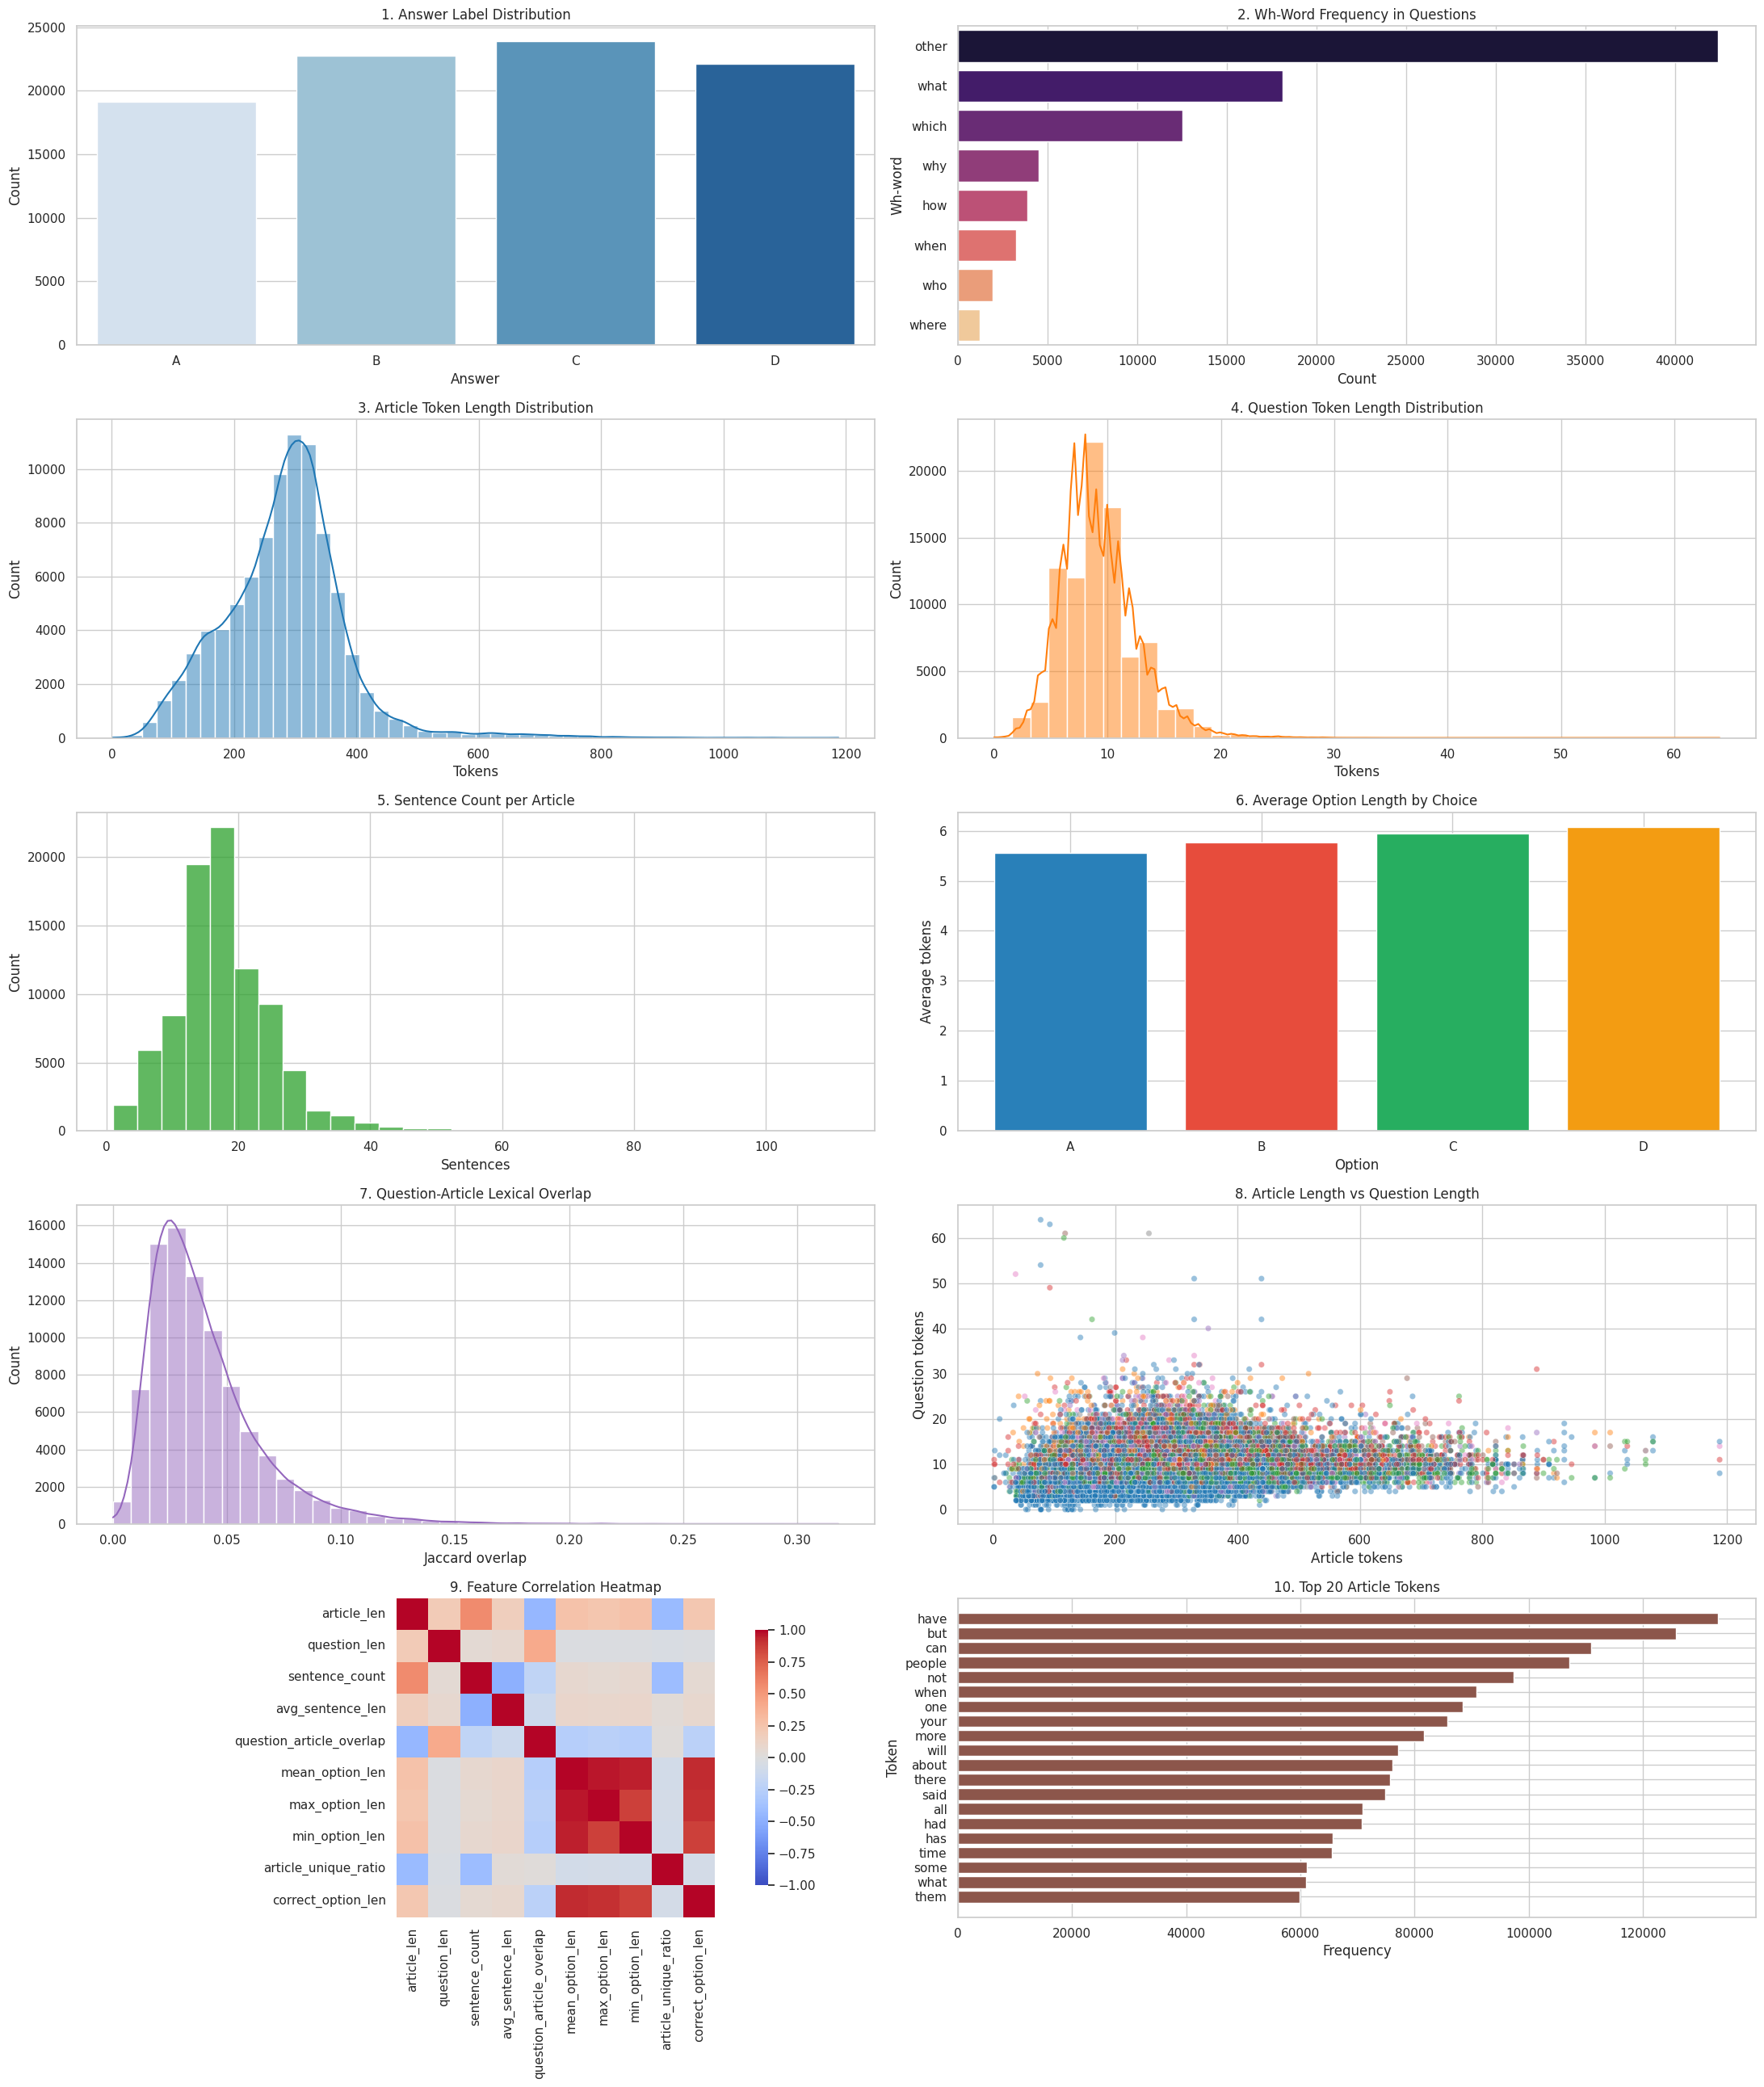

Saved figure to: /kaggle/working/report/eda_figures/eda_overview.png


In [17]:
fig, axes = plt.subplots(5, 2, figsize=(22, 26))
axes = axes.flatten()

# 1) Answer label distribution
sns.countplot(x="answer", data=df, order=["A", "B", "C", "D"], palette="Blues", ax=axes[0])
axes[0].set_title("1. Answer Label Distribution")
axes[0].set_xlabel("Answer")
axes[0].set_ylabel("Count")

# 2) Wh-word distribution
wh_order = df["wh_word"].value_counts().index.tolist()
sns.countplot(y="wh_word", data=df, order=wh_order, palette="magma", ax=axes[1])
axes[1].set_title("2. Wh-Word Frequency in Questions")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("Wh-word")

# 3) Article length
sns.histplot(df["article_len"], bins=50, kde=True, color="#1f77b4", ax=axes[2])
axes[2].set_title("3. Article Token Length Distribution")
axes[2].set_xlabel("Tokens")
axes[2].set_ylabel("Count")

# 4) Question length
sns.histplot(df["question_len"], bins=40, kde=True, color="#ff7f0e", ax=axes[3])
axes[3].set_title("4. Question Token Length Distribution")
axes[3].set_xlabel("Tokens")
axes[3].set_ylabel("Count")

# 5) Sentence count
sns.histplot(df["sentence_count"], bins=30, kde=False, color="#2ca02c", ax=axes[4])
axes[4].set_title("5. Sentence Count per Article")
axes[4].set_xlabel("Sentences")
axes[4].set_ylabel("Count")

# 6) Average option length
option_means = [df[col].apply(lambda text: len(tokenize(text))).mean() for col in ["A", "B", "C", "D"]]
axes[5].bar(["A", "B", "C", "D"], option_means, color=["#2980b9", "#e74c3c", "#27ae60", "#f39c12"])
axes[5].set_title("6. Average Option Length by Choice")
axes[5].set_xlabel("Option")
axes[5].set_ylabel("Average tokens")

# 7) Lexical overlap between question and article
sns.histplot(df["question_article_overlap"], bins=40, kde=True, color="#9467bd", ax=axes[6])
axes[6].set_title("7. Question-Article Lexical Overlap")
axes[6].set_xlabel("Jaccard overlap")
axes[6].set_ylabel("Count")

# 8) Article length vs question length
sns.scatterplot(
    data=df,
    x="article_len",
    y="question_len",
    hue="wh_word",
    alpha=0.45,
    s=28,
    palette="tab10",
    ax=axes[7],
    legend=False,
)
axes[7].set_title("8. Article Length vs Question Length")
axes[7].set_xlabel("Article tokens")
axes[7].set_ylabel("Question tokens")

# 9) Correlation heatmap for engineered numeric features
corr_cols = [
    "article_len",
    "question_len",
    "sentence_count",
    "avg_sentence_len",
    "question_article_overlap",
    "mean_option_len",
    "max_option_len",
    "min_option_len",
    "article_unique_ratio",
    "correct_option_len",
]
corr = df[corr_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True, ax=axes[8], cbar_kws={"shrink": 0.8})
axes[8].set_title("9. Feature Correlation Heatmap")

# 10) Top article tokens
article_counter = Counter()
for text in df["article"].astype(str):
    article_counter.update(filtered_tokens(text))
most_common_article = article_counter.most_common(20)
if most_common_article:
    tokens, counts = zip(*most_common_article)
    axes[9].barh(list(reversed(tokens)), list(reversed(counts)), color="#8c564b")
axes[9].set_title("10. Top 20 Article Tokens")
axes[9].set_xlabel("Frequency")
axes[9].set_ylabel("Token")

plt.tight_layout()
figure_dir = os.path.join(PROJECT_ROOT, "report", "eda_figures")
os.makedirs(figure_dir, exist_ok=True)
figure_path = os.path.join(figure_dir, "eda_overview.png")
plt.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved figure to:", figure_path)


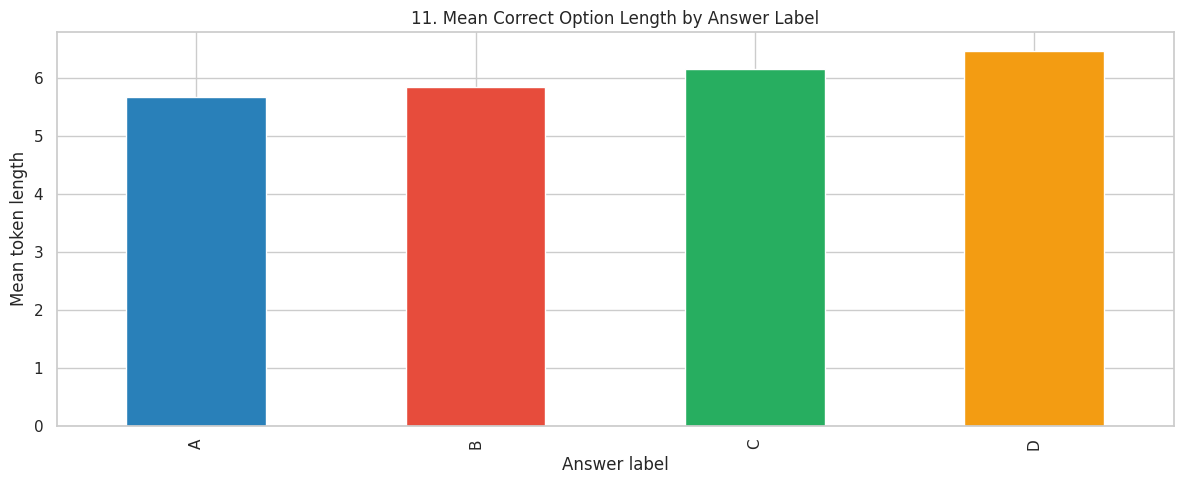

In [18]:
# 11) Correct option length by answer label
label_order = ['A', 'B', 'C', 'D']
correct_len_by_label = df.groupby('answer')['correct_option_len'].mean().reindex(label_order)
correct_len_by_label.plot(kind='bar', color=['#2980b9','#e74c3c','#27ae60','#f39c12'])
plt.title('11. Mean Correct Option Length by Answer Label')
plt.xlabel('Answer label')
plt.ylabel('Mean token length')
plt.tight_layout()
plt.show()

In [19]:
summary_out_dir = os.path.join(PROJECT_ROOT, "report")
os.makedirs(summary_out_dir, exist_ok=True)
summary_path = os.path.join(summary_out_dir, "eda_summary.csv")

summary_table.reset_index(names="feature").to_csv(summary_path, index=False)
print("Saved summary table to:", summary_path)
print("\nEDA pipeline complete. The notebook now covers label balance, lengths, overlap, token frequency, and engineered feature relationships.")


Saved summary table to: /kaggle/working/report/eda_summary.csv

EDA pipeline complete. The notebook now covers label balance, lengths, overlap, token frequency, and engineered feature relationships.
